# Capítulo 2 — Introduction to Machine Learning

Siguiendo [dmol.pub/ml/introduction.html](https://dmol.pub/ml/introduction.html).

Entorno: kernel `Python (dmol)`. Datos ya descargados en `../data/`.

## 2.1 The Ingredients

Los tres ingredientes de cualquier modelo de ML:

1. **Datos de entrada** — lo que observas de cada ejemplo. En química: una molécula, descrita de algún modo numérico.
2. **El modelo** — una función $\hat{y} = f(\vec{x};\,\vec{w})$ con parámetros ajustables $\vec{w}$.
3. **La función de pérdida (loss)** — un número que mide cuánto se equivoca el modelo. Entrenar = mover $\vec{w}$ para bajar ese número.

Vocabulario que se repite todo el libro:

| Término | Símbolo | Qué es aquí |
|---|---|---|
| *feature* (variable de entrada) | $\vec{x}$ | descriptores moleculares: peso molecular, logP, TPSA... |
| *label* (etiqueta, lo que queremos predecir) | $y$ | la solubilidad medida |
| *parámetros / pesos* | $\vec{w}$ | lo que el entrenamiento ajusta |
| *predicción* | $\hat{y}$ | lo que el modelo dice |

## 2.2 Supervised Learning

**Aprendizaje supervisado**: predecir $y$ a partir de $\vec{x}$ usando un modelo entrenado con ejemplos donde ya conocemos $y$.
"Supervisado" = durante el entrenamiento le enseñamos al algoritmo la respuesta correcta.

**Aprendizaje no supervisado**: buscar estructura en los datos *sin* etiquetas (lo veremos en 2.4 con clustering).

El dataset del capítulo es **AqSolDB**: ~10.000 compuestos con su solubilidad en agua medida.
La solubilidad viene en **log molaridad** — es decir, $\log_{10}$ de la concentración en mol/L de la
disolución saturada. Valores negativos = poco soluble; un $-8$ es prácticamente insoluble y un $0$ es 1 mol/L.

> Se usa el logaritmo porque la solubilidad abarca muchísimos órdenes de magnitud. En escala lineal
> el modelo solo "vería" los compuestos muy solubles; en escala log todos pesan parecido.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

### Cargar los datos

El libro descarga el CSV por URL en cada ejecución; nosotros lo tenemos cacheado en `data/`
(mismo fichero, `curated-solubility-dataset.csv`).

In [2]:
soldata = pd.read_csv("../data/curated-solubility-dataset.csv")
print("filas (compuestos):", soldata.shape[0])
print("columnas:", soldata.shape[1])

filas (compuestos): 9982
columnas: 26


In [3]:
soldata.head()

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,MolLogP,MolMR,HeavyAtomCount,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.0,1,G1,392.510,3.9581,102.4454,23.0,0.0,0.0,2.0,17.0,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.0,1,G1,169.183,2.4055,51.9012,13.0,1.0,1.0,2.0,0.0,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.0,1,G1,140.569,2.1525,36.8395,9.0,1.0,0.0,2.0,1.0,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.0,1,G1,756.226,8.1161,200.7106,53.0,6.0,2.0,7.0,10.0,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.0,1,G1,422.525,2.4854,119.0760,31.0,6.0,0.0,6.0,12.0,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934


### ¿Qué es feature y qué es label?

Las 26 columnas no son todas iguales. Hay tres grupos:

- **Identificación / metadatos** — `ID`, `Name`, `InChI`, `InChIKey`, `SMILES`, `SD`, `Ocurrences`, `Group`.
  Describen de dónde sale el dato o qué molécula es, pero no entran al modelo.
- **Label** — `Solubility`. Lo único que queremos predecir.
- **Features** — de `MolWt` en adelante: 17 descriptores calculados con RDKit a partir de la estructura.

El truco del libro para separarlos sin escribir los 17 nombres a mano:

In [4]:
features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]

print(f"{len(feature_names)} features:")
for name in feature_names:
    print("  -", name)

17 features:
  - MolWt
  - MolLogP
  - MolMR
  - HeavyAtomCount
  - NumHAcceptors
  - NumHDonors
  - NumHeteroatoms
  - NumRotatableBonds
  - NumValenceElectrons
  - NumAromaticRings
  - NumSaturatedRings
  - NumAliphaticRings
  - RingCount
  - TPSA
  - LabuteASA
  - BalabanJ
  - BertzCT


Qué significa cada descriptor, en cristiano:

| Feature | Qué mide | Por qué puede importar para solubilidad |
|---|---|---|
| `MolWt` | peso molecular | moléculas grandes suelen ser menos solubles |
| `MolLogP` | lipofilia estimada (log P octanol/agua) | **el más directo**: alto logP = prefiere la fase orgánica |
| `MolMR` | refractividad molar (~polarizabilidad × volumen) | relacionado con tamaño y polarizabilidad |
| `HeavyAtomCount` | átomos distintos de H | otra medida de tamaño |
| `NumHAcceptors` / `NumHDonors` | aceptores/dadores de puente de H | puentes de H con el agua = más soluble |
| `NumHeteroatoms` | átomos que no son C ni H | polaridad |
| `NumRotatableBonds` | enlaces que giran libremente | flexibilidad conformacional |
| `NumValenceElectrons` | electrones de valencia | tamaño electrónico |
| `NumAromaticRings`, `NumSaturatedRings`, `NumAliphaticRings`, `RingCount` | anillos por tipo | aromáticos planos apilan y bajan solubilidad |
| `TPSA` | área superficial polar topológica (Å²) | superficie que puede solvatar el agua |
| `LabuteASA` | área superficial accesible total | tamaño de la superficie |
| `BalabanJ`, `BertzCT` | índices topológicos (ramificación, complejidad) | forma de la molécula |

Fíjate en la idea de fondo: hemos convertido *una molécula* en **un vector de 17 números**.
Eso es lo que hace posible el ML aquí — y es exactamente el punto débil que los capítulos 8+
(graph neural networks) van a atacar, porque estos 17 números tiran a la basura la conectividad real.

In [5]:
# la label, por separado
labels = soldata["Solubility"]
features = soldata[feature_names]

print("X (features):", features.shape)   # una fila por molécula, una columna por descriptor
print("y (label):   ", labels.shape)
print()
print("rango de solubilidad (log mol/L):")
print(f"  mínimo  {labels.min():.2f}")
print(f"  mediana {labels.median():.2f}")
print(f"  máximo  {labels.max():.2f}")

X (features): (9982, 17)
y (label):    (9982,)

rango de solubilidad (log mol/L):
  mínimo  -13.17
  mediana -2.62
  máximo  2.14


Un rango de casi 14 unidades log = **14 órdenes de magnitud** de diferencia en concentración
entre el compuesto menos y el más soluble del dataset.

---

### Resumen de 2.2

- Supervisado = tenemos pares $(\vec{x}_i,\, y_i)$ y aprendemos la función que los conecta.
- Aquí: $\vec{x}_i \in \mathbb{R}^{17}$ (descriptores RDKit), $y_i \in \mathbb{R}$ (log solubilidad).
- $N = 9982$ moléculas.

**Siguiente**: 2.3, donde miramos los datos de verdad (distribuciones, moléculas extremas,
correlación feature–label) y construimos el primer modelo lineal entrenado con descenso de gradiente.

---

## 2.3 Explorando los datos

Antes de entrenar nada, hay que **mirar** los datos. Es la parte que más se salta la gente y la que más
errores caza: distribuciones raras, valores imposibles, unidades equivocadas.

En este primer trozo:
1. Convertimos una fila del CSV en una molécula de verdad y la dibujamos (RDKit).
2. Vemos cómo se reparten las solubilidades (histograma).
3. Miramos las moléculas de los dos extremos, a ver si la química cuadra.

### 2.3.1 RDKit: de texto a molécula

**RDKit** es la librería de quimioinformática estándar. Su objeto central es el `Mol`: una molécula
en memoria, con sus átomos, enlaces y cargas. Todo lo demás (dibujar, calcular descriptores,
buscar subestructuras) se hace sobre un `Mol`.

En el CSV la molécula viene guardada como **texto**, en dos formatos:

| Formato | Ejemplo | Para qué sirve |
|---|---|---|
| **SMILES** | `Clc1ccc(C=O)cc1` | Legible por humanos, compacto. El estándar para escribir moléculas a mano. Una misma molécula admite varios SMILES válidos. |
| **InChI** | `InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H` | Feo pero **canónico**: una molécula = exactamente una cadena InChI. Por eso se usa para deduplicar bases de datos. |

Ese texto no se puede dibujar ni analizar tal cual. Hay que *parsearlo* a un `Mol`:
- `rdkit.Chem.MolFromSmiles(texto)` → `Mol`
- `rdkit.Chem.MolFromInchi(texto)` → `Mol`

El libro usa InChI porque es el campo canónico del dataset. Importamos también `IPythonConsole`,
que es lo que le dice a Jupyter "cuando te enseñe un `Mol`, dibújalo" en vez de escribir
`<rdkit.Chem.rdchem.Mol object at 0x...>`.

nombre:      N,N,N-trimethyloctadecan-1-aminium bromide
SMILES:      [Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C
solubilidad: -3.62 log mol/L
formula:     C21H46BrN


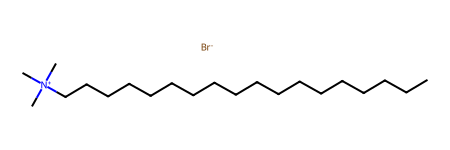

In [6]:
import rdkit
import rdkit.Chem
import rdkit.Chem.Draw
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Draw import IPythonConsole   # hace que Jupyter dibuje los Mol

# cogemos la primera molecula del dataset
row = soldata.iloc[0]
mol = rdkit.Chem.MolFromInchi(row["InChI"])

print("nombre:     ", row["Name"])
print("SMILES:     ", row["SMILES"])
print("solubilidad:", round(row["Solubility"], 2), "log mol/L")
print("formula:    ", rdMolDescriptors.CalcMolFormula(mol))
mol

Ahí está: bromuro de trimetiloctadecilamonio, un tensioactivo catiónico. Cadena C18 larga y apolar,
cabeza amonio cuaternario cargada. Su solubilidad es −3.62.

Fíjate en que RDKit ha dibujado el `[Br-]` separado: en el SMILES, el punto (`.`) significa
"componentes desconectados". Para RDKit esto es **un solo `Mol` con dos fragmentos**, y los
descriptores (peso molecular, etc.) se calculan sobre el conjunto. Es un detalle que en datasets
con sales causa bastantes sorpresas.

### 2.3.2 ¿Cómo se reparte la solubilidad?

Un **histograma** parte el rango de valores en intervalos (*bins*) y cuenta cuántas moléculas caen en
cada uno. Sirve para ver de un vistazo dónde se concentran los datos y si hay colas raras.

Lo dibujamos con `seaborn` (una capa por encima de `matplotlib` que hace gráficas estadísticas con
una línea). El libro usa `sns.distplot`, que **ya no existe** en seaborn 0.13 — su sustituto es
`sns.histplot`.

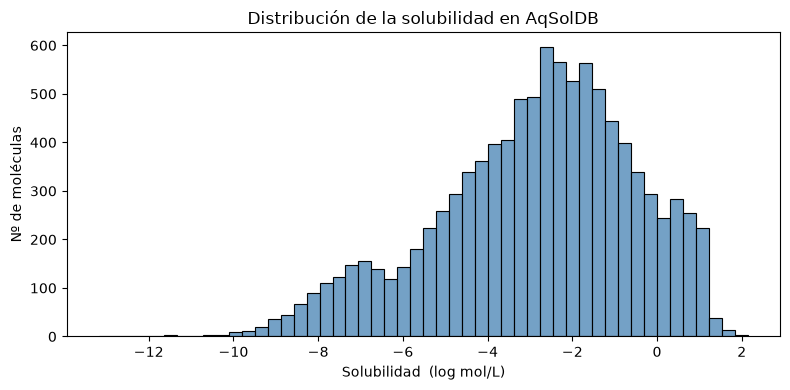

count    9982.00
mean       -2.89
std         2.37
min       -13.17
25%        -4.33
50%        -2.62
75%        -1.21
max         2.14


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(soldata["Solubility"], bins=50, ax=ax, color="steelblue")
ax.set_xlabel("Solubilidad  (log mol/L)")
ax.set_ylabel("Nº de moléculas")
ax.set_title("Distribución de la solubilidad en AqSolDB")

fig.tight_layout()
fig.savefig("../figuras/02_distribucion_solubilidad.png", dpi=150)
plt.show()

# los mismos numeros, en texto
print(soldata["Solubility"].describe().round(2).to_string())

Cómo se lee esto:

- El grueso de los datos está entre **−6 y 0**, con el pico sobre −2.5. Tiene sentido: las bases de
  datos de solubilidad se llenan de fármacos y compuestos industriales, que son moléculas de
  tamaño medio y solubilidad moderada.
- Hay una **cola larga hacia la izquierda** que llega a −13. Son los extremadamente insolubles.
  Son pocos, y eso importa: el modelo verá muy pocos ejemplos de esa zona, así que ahí predecirá mal.
- Por la derecha la cosa se corta en torno a +2. Es un límite físico, no un artefacto: por encima
  de ~100 mol/L ya no hablas de una disolución, hablas del líquido puro.
- `std` (desviación típica) ≈ 2.4. Guárdate este número: **es la vara de medir**. Un modelo que
  prediga siempre la media se equivocaría, de media, unas 2.4 unidades. Cualquier modelo que
  entrenemos tiene que bajar claramente de ahí para valer algo.

### 2.3.3 Los extremos

Ordenamos el dataset por solubilidad y miramos las 3 moléculas de cada extremo. Es la mejor
comprobación de cordura que existe: si la química de los extremos no cuadra, algo está mal en los datos.

`sort_values` devuelve una copia ordenada; `MolsToGridImage` dibuja varias moléculas en rejilla con
un pie de texto (`legends`) para cada una.

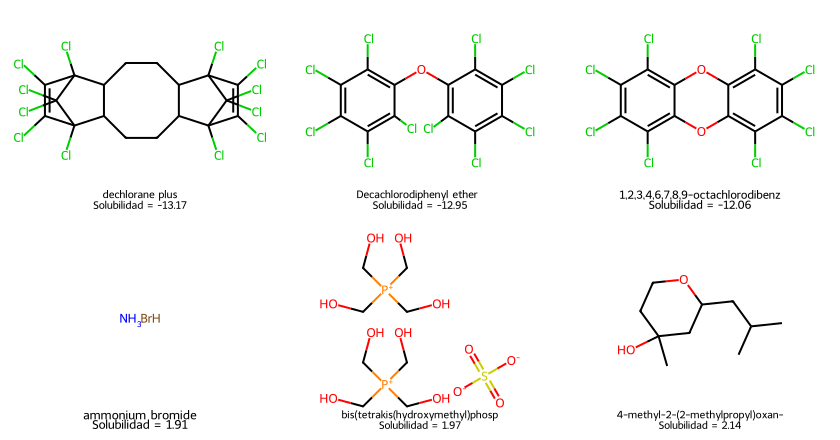

In [8]:
sorted_data = soldata.sort_values("Solubility")

extremos = pd.concat([sorted_data.head(3), sorted_data.tail(3)])

mols = [rdkit.Chem.MolFromInchi(inchi) for inchi in extremos["InChI"]]
legends = [
    f"{name[:32]}\nSolubilidad = {sol:.2f}"
    for name, sol in zip(extremos["Name"], extremos["Solubility"])
]

rdkit.Chem.Draw.MolsToGridImage(
    mols, molsPerRow=3, subImgSize=(280, 220), legends=legends
)

**Fila de arriba — los 3 más insolubles:**

| Molécula | Solubilidad | MolLogP | TPSA | Dadores H |
|---|---|---|---|---|
| dechlorane plus | −13.17 | 9.72 | 0.00 | 0 |
| decaclorodifenil éter | −12.95 | 10.01 | 9.23 | 0 |
| octaclorodibenzo-*p*-dioxina | −12.06 | 8.81 | 18.46 | 0 |

Los tres son **organoclorados policíclicos**: un retardante de llama y dos contaminantes
persistentes clásicos. El patrón salta a la vista — `MolLogP` entre 9 y 10, `TPSA` prácticamente 0,
**cero dadores de puente de hidrógeno**. Son superficies de cloro sin un solo sitio donde el agua
pueda agarrarse. Solubilidad de 10⁻¹³ mol/L: eso es del orden de una molécula por litro, y es
exactamente la razón por la que estos compuestos se bioacumulan y no se van nunca del medio ambiente.

**Fila de abajo — los 3 más solubles:**

| Molécula | Solubilidad | MolLogP | TPSA | Dadores H |
|---|---|---|---|---|
| bromuro de amonio | +1.91 | −2.62 | 36.5 | 1 |
| sulfato de bis(tetrakis(hidroximetil)fosfonio) | +1.97 | −3.73 | 242.1 | 8 |
| 4-metil-2-(2-metilpropil)oxan-4-ol | +2.14 | 1.96 | 29.5 | 1 |

Las dos primeras son **sales**: se disocian en iones y el agua las solvata sin esfuerzo. Mira los
números, son el espejo exacto de los de arriba — logP **negativo** (prefiere el agua al octanol),
TPSA alta, dadores de H de sobra.

**Pero la tercera desentona.** Un alcohol neutro con logP +1.96 y una sola TPSA de 29 no debería
ser el compuesto más soluble de las 9982 moléculas del dataset. O el dato experimental es malo, o
es un compuesto miscible con agua cuyo valor se anotó de forma distinta al resto.

Esto no es un estorbo, es la lección: **los datos experimentales reales traen ruido y errores**, y en
la cola del dataset es donde se acumulan. Un modelo entrenado con esto nunca podrá ser más preciso
que las medidas de las que aprende. Lo veremos otra vez en el capítulo 3, cuando hablemos de
cuánto error es *irreducible*.

Conclusión: los datos son coherentes en lo esencial. Podemos seguir.

---

### 2.3.4 ¿Qué descriptores predicen algo?

Tenemos 17 features. Antes de meterlas todas en un modelo conviene preguntarse cuáles llevan
información sobre la solubilidad y cuáles son ruido.

La herramienta es el **scatter plot** (diagrama de dispersión): un punto por molécula, con el
descriptor en el eje X y la solubilidad en el eje Y. 9982 puntos por gráfica.

Lo que buscamos es **tendencia**: si al moverte hacia la derecha los puntos bajan (o suben) de forma
sistemática, ese descriptor predice. Si la nube es un borrón sin dirección, no.

Dos trucos de dibujo que hacen falta con tantos puntos:
- `s=3` — puntos diminutos.
- `alpha=0.15` — cada punto es un 15 % opaco, así donde se amontonan sale más oscuro. Sin esto
  tendrías una mancha negra uniforme y no verías dónde está la densidad.

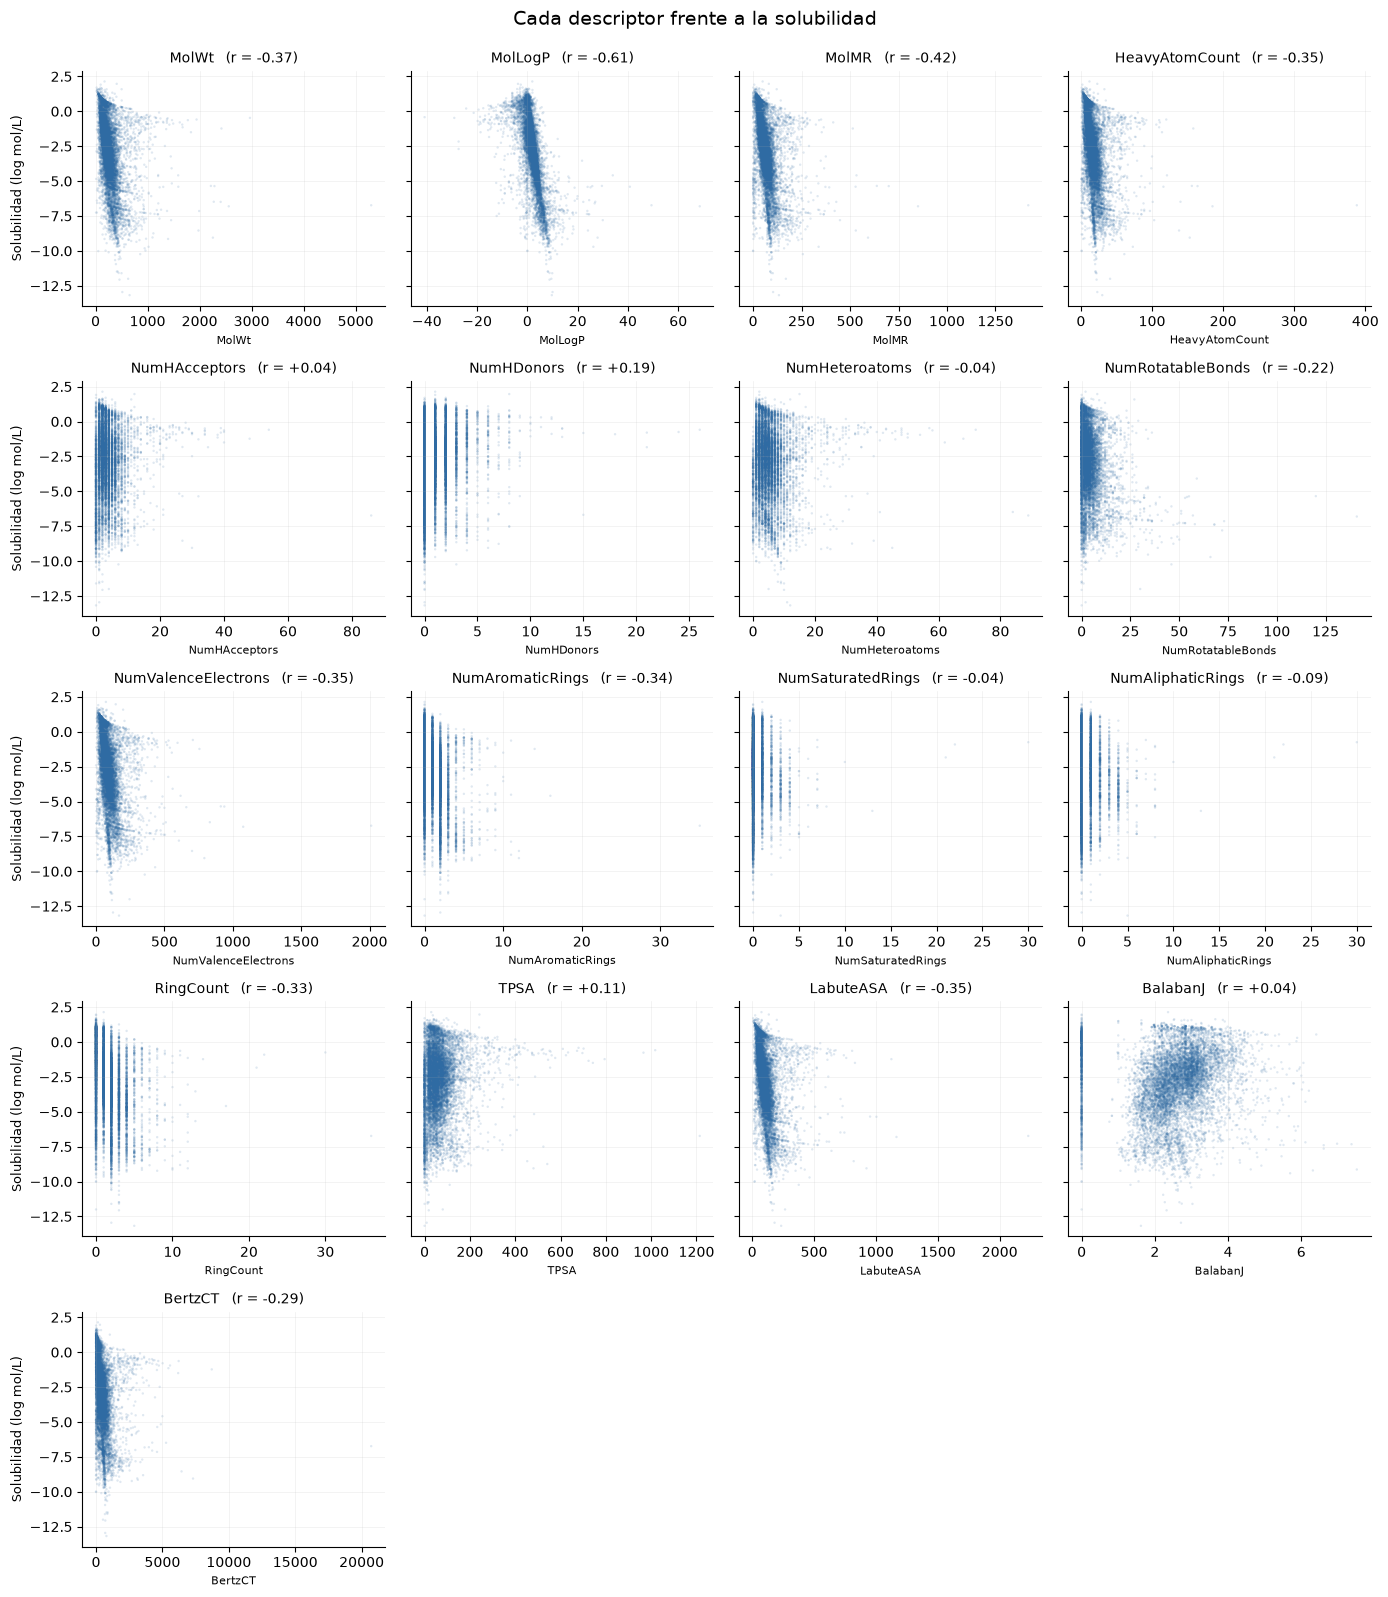

In [9]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(14, 16), sharey=True)
axes = axes.flatten()

for ax, feat in zip(axes, feature_names):
    r = np.corrcoef(soldata[feat], soldata["Solubility"])[0, 1]
    ax.scatter(soldata[feat], soldata["Solubility"], s=3, alpha=0.15, color="#2f6ba3",
               edgecolors="none", rasterized=True)
    ax.set_title(f"{feat}   (r = {r:+.2f})", fontsize=10)
    ax.set_xlabel(feat, fontsize=8)
    ax.grid(alpha=0.2, linewidth=0.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

for ax in axes[len(feature_names):]:      # huecos sobrantes de la rejilla
    ax.remove()

for ax in axes[:len(feature_names)]:
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("Solubilidad (log mol/L)", fontsize=9)

fig.suptitle("Cada descriptor frente a la solubilidad", fontsize=14, y=0.995)
fig.tight_layout()
fig.savefig("../figuras/02_scatter_features.png", dpi=110, bbox_inches="tight")
plt.show()

Qué se ve, panel a panel:

- **`MolLogP`** es el único con una tendencia limpia y marcada: la nube cae en diagonal de izquierda
  a derecha. Era de esperar — logP mide literalmente la preferencia octanol/agua, casi la misma
  magnitud física que intentamos predecir, medida de otra forma.
- **`MolWt`, `MolMR`, `HeavyAtomCount`, `LabuteASA`, `NumValenceElectrons`, `BertzCT`** comparten
  la misma forma: nube apretada a la izquierda, cola larga a la derecha, pendiente descendente
  suave. **Son todas medidas de "cómo de grande es la molécula"**, así que dicen casi lo mismo.
  Apunta esto, tiene consecuencias.
- **`NumHDonors` y `TPSA`** sí se inclinan, pero **hacia arriba** y muy poco. La dirección es la
  químicamente correcta (más puentes de H → más soluble); lo flojo de la pendiente tiene
  explicación, y la vemos justo debajo.
- Los **contadores de anillos** y `NumHDonors` forman bandas verticales, porque solo toman valores
  enteros (0, 1, 2, 3...). Un scatter no es el gráfico ideal para variables discretas, pero sirve
  para ver la tendencia.
- **`BalabanJ`** tiene una columna densa y sospechosa de puntos justo en x = 0. Ese es el valor que
  RDKit devuelve cuando el índice no está definido — típicamente en moléculas con fragmentos
  desconectados, o sea las sales. No son ceros medidos, son "no calculable" disfrazado de cero.
  Lo confirmamos con números abajo.

#### El coeficiente de correlación

Mirar 17 nubes de puntos está bien, pero queremos un número. El **coeficiente de correlación de
Pearson**, $r$, resume la relación **lineal** entre dos variables:

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\sqrt{\sum_i (y_i - \bar{y})^2}} $$

No hace falta memorizarla; lo que hace es: para cada molécula mira si el descriptor está por encima
o por debajo de *su* media, y si la solubilidad está por encima o por debajo de *su* media, y premia
las veces que coinciden. El denominador lo normaliza para que el resultado no dependa de las unidades.

Cómo se lee:

| $r$ | Significa |
|---|---|
| $+1$ | recta perfecta ascendente |
| $+0.5$ | tendencia a subir, clara pero con mucha dispersión |
| $0$ | ninguna relación **lineal** |
| $-0.5$ | tendencia a bajar |
| $-1$ | recta perfecta descendente |

Dos avisos importantes:

1. **Solo detecta rectas.** Una relación en forma de U perfecta da $r \approx 0$ aunque sea una
   dependencia total. $r = 0$ significa "no hay *recta*", no "no hay relación".
2. **Correlación no es causalidad.** Aquí da igual — queremos predecir, no explicar mecanismos.

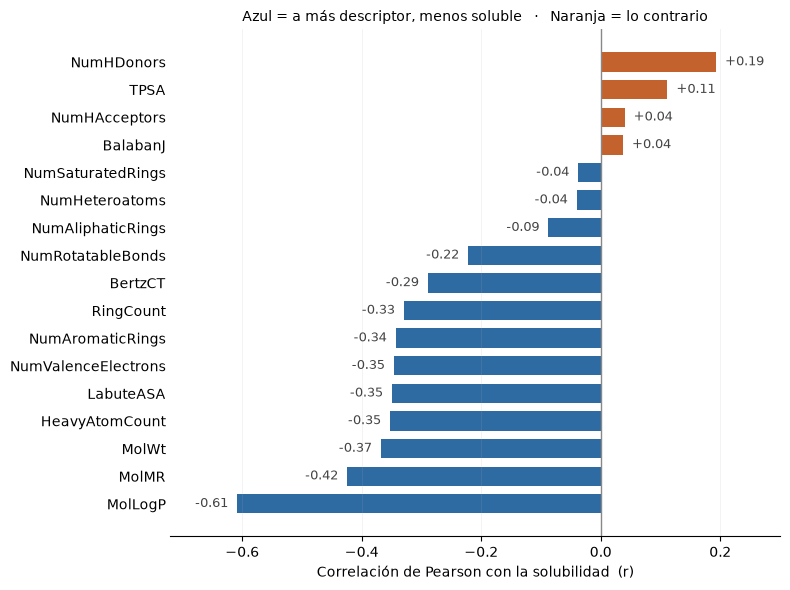

moléculas con BalabanJ = 0: 400
de ellas, sales (SMILES con '.'): 363


In [10]:
corr = soldata[feature_names].corrwith(soldata["Solubility"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colores = ["#2f6ba3" if v < 0 else "#c4622d" for v in corr]
ax.barh(corr.index, corr.values, color=colores, height=0.7)

for feat, v in corr.items():                       # etiqueta directa en cada barra
    ax.text(v + (0.015 if v > 0 else -0.015), feat, f"{v:+.2f}",
            va="center", ha="left" if v > 0 else "right", fontsize=9, color="#444")

ax.axvline(0, color="#888", linewidth=1)
ax.set_xlim(-0.72, 0.30)
ax.set_xlabel("Correlación de Pearson con la solubilidad  (r)")
ax.set_title("Azul = a más descriptor, menos soluble   ·   Naranja = lo contrario", fontsize=10)
ax.grid(axis="x", alpha=0.2, linewidth=0.5)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)

fig.tight_layout()
fig.savefig("../figuras/02_correlaciones.png", dpi=150)
plt.show()

# comprobamos la sospecha de BalabanJ
print("moléculas con BalabanJ = 0:", (soldata["BalabanJ"] == 0).sum())
print("de ellas, sales (SMILES con '.'):",
      (soldata.loc[soldata["BalabanJ"] == 0, "SMILES"].str.contains(r"\.", regex=True)).sum())

El ranking real, ordenado por $|r|$:

| Descriptor | $r$ | Lectura química |
|---|---|---|
| `MolLogP` | **−0.61** | **El campeón.** Lipofilia alta → insoluble. Es casi la misma magnitud física que predecimos. |
| `MolMR` | −0.42 | Refractividad molar ≈ tamaño × polarizabilidad. |
| `MolWt` | −0.37 | Más pesada, menos soluble. |
| `HeavyAtomCount` | −0.35 | Lo mismo, contando átomos. |
| `LabuteASA` | −0.35 | Lo mismo, midiendo superficie. |
| `NumValenceElectrons` | −0.35 | Lo mismo, contando electrones. |
| `NumAromaticRings` | −0.34 | Anillos planos que apilan bien entre sí y mal con el agua. |
| `RingCount` | −0.33 | Ídem, todos los anillos. |
| `BertzCT` | −0.29 | Complejidad topológica (correlaciona con tamaño). |
| `NumRotatableBonds` | −0.22 | Cadenas flexibles largas → suelen ser apolares. |
| `NumHDonors` | **+0.19** | **Positiva**, como manda la química: más −OH/−NH, más soluble. |
| `TPSA` | **+0.11** | Positiva también: más superficie polar, más soluble. |
| `NumAliphaticRings` | −0.09 | |
| `NumHeteroatoms` | −0.04 | |
| `NumHAcceptors` | +0.04 | |
| `NumSaturatedRings` | −0.04 | |
| `BalabanJ` | +0.04 | Contaminado por los ceros falsos. |

Fíjate en el patrón: **todo lo que mide "tamaño / hidrofobia" sale negativo; todo lo que mide
"capacidad de puente de hidrógeno" sale positivo.** Los signos cuadran con la química de manual.
Lo que falla es la *magnitud* de los positivos.

**Las cuatro conclusiones que nos llevamos a la sección siguiente:**

1. **Ninguna feature suelta basta.** La mejor, `MolLogP`, da $r = -0.61$. Al cuadrado,
   $r^2 = 0.37$: explicaría un **37 %** de la variación de la solubilidad y dejaría el **63 %**
   sin explicar. De ahí la necesidad de un modelo que combine las 17.

2. **Hay features redundantes.** `MolWt`, `MolMR`, `HeavyAtomCount`, `LabuteASA` y
   `NumValenceElectrons` son cinco maneras de decir "tamaño", y sus correlaciones son casi
   idénticas (−0.35 a −0.42). Eso se llama **multicolinealidad**: el modelo puede repartir el mismo
   efecto entre las cinco de infinitas formas distintas, así que sus pesos saldrán inestables y
   **no se podrán leer como "importancia"**. Para predecir da igual; para explicar, no.

3. **$r$ bajo no significa feature inútil.** `NumHDonors` (+0.19) y `TPSA` (+0.11) son
   químicamente decisivas y aquí salen flojas. El motivo es que compiten con el tamaño: una
   molécula grande tiene más dadores de H (solubiliza) pero también más superficie apolar
   (insolubiliza), y en una correlación de a pares los dos efectos se cancelan. Un modelo
   multivariable puede separar ambas cosas; una correlación a pares no. **No las tiramos.**

4. **`BalabanJ` está sucio.** Hay **400 moléculas** con `BalabanJ = 0`, que no es un cero real sino
   el "no calculable" que devuelve RDKit para estructuras con fragmentos desconectados (sales).
   El modelo lineal se lo va a creer como si fuera un valor medido.

Ya sabemos con qué materia prima contamos. En 2.3.5 montamos el primer modelo.

---

### 2.3.5 El modelo lineal y la función de pérdida

Ahora construimos las dos piezas del modelo. **Todavía no entrenamos nada** — eso es 2.3.6.
Aquí solo definimos:

1. **El modelo**: la fórmula que convierte 17 números en una predicción de solubilidad.
2. **La pérdida**: el número que mide cuánto se equivoca.

#### El modelo lineal

El modelo más simple posible: multiplicar cada descriptor por un peso y sumarlo todo.

$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_{17} x_{17} + b$$

En notación compacta, con $\vec{w}$ y $\vec{x}$ como vectores de 17 componentes:

$$\hat{y} = \vec{w} \cdot \vec{x} + b$$

Las piezas, una a una:

| Símbolo | Qué es | Forma | ¿Se aprende? |
|---|---|---|---|
| $\vec{x}$ | los 17 descriptores de **una** molécula | 17 números | no, son el dato |
| $\vec{w}$ | **pesos**: cuánto cuenta cada descriptor | 17 números | **sí** |
| $b$ | **bias** (sesgo, u ordenada en el origen) | 1 número | **sí** |
| $\hat{y}$ | la solubilidad predicha | 1 número | es la salida |

Intuición de cada parte:

- **El peso $w_j$** dice cuánto y en qué sentido influye el descriptor $j$. Si `MolLogP` tiene
  $w = -0.5$, el modelo está diciendo "por cada unidad de logP, baja media unidad de solubilidad".
  Un peso 0 es el modelo diciendo "este descriptor me da igual".
- **El bias $b$** es el valor de partida cuando todos los descriptores valen 0. Sin él, el modelo
  estaría obligado a pasar por el origen, y aquí eso no tiene sentido: la solubilidad media es
  −2.89, no 0. El bias le permite centrarse donde están los datos.

Esto es una **recta generalizada a 17 dimensiones** (técnicamente, un hiperplano). Es el modelo más
tonto que existe, y por eso es el que se hace primero: marca el listón que todo lo demás tiene que superar.

> Y ojo, no es un juguete: el capítulo 7 enseña que una red neuronal es, básicamente, **muchas de
> estas capas lineales apiladas** con una función no lineal entre medias. Si entiendes esto,
> entiendes el ladrillo con el que está hecho todo el deep learning.

#### El producto escalar y JAX

$\vec{w} \cdot \vec{x}$ es el **producto escalar**: multiplicas componente a componente y sumas.

Se escribe `jnp.dot(x, w)`, donde `jnp` es **JAX**. ¿Qué es JAX?

> JAX es numpy con dos superpoderes: sabe **derivar cualquier función que escribas**
> (lo que necesitaremos en 2.3.6 para entrenar) y sabe compilar y correr en GPU.
> La API es casi idéntica a numpy: donde ponías `np.dot` pones `jnp.dot`.

Lo usamos ya desde aquí para no reescribir el código después. Si en este punto sustituyeras `jnp`
por `np` el resultado sería exactamente el mismo.

In [11]:
import jax
import jax.numpy as jnp


def linear_model(x, w, b):
    """Predice la solubilidad. x puede ser una molécula (17,) o un lote (N, 17)."""
    return jnp.dot(x, w) + b


# prueba con numeros inventados para entender las formas
x_falso = jnp.array([1.0, 2.0, 3.0])     # 3 features de una molecula imaginaria
w_falso = jnp.array([0.5, 0.0, -1.0])    # pesos inventados
b_falso = 2.0

print("x:", x_falso)
print("w:", w_falso)
print("producto escalar:", jnp.dot(x_falso, w_falso), " = 1*0.5 + 2*0.0 + 3*(-1.0) = -2.5")
print("+ bias:", linear_model(x_falso, w_falso, b_falso), " = -2.5 + 2.0")

x: [1. 2. 3.]
w: [ 0.5  0.  -1. ]
producto escalar: -2.5  = 1*0.5 + 2*0.0 + 3*(-1.0) = -2.5
+ bias: -0.5  = -2.5 + 2.0


#### La misma fórmula, para las 9982 moléculas a la vez

Aquí está lo que hace que esto sea rápido. En vez de recorrer las moléculas con un bucle,
apilamos todas las filas en una **matriz** $X$ de forma $(9982, 17)$ y hacemos **un solo** producto
matriz-vector:

$$\underbrace{X}_{(9982,\,17)} \cdot \underbrace{\vec{w}}_{(17,)} = \underbrace{\vec{\hat{y}}}_{(9982,)}$$

La regla de las formas: el $17$ del final de $X$ se "come" con el $17$ de $\vec{w}$, y lo que
sobra ($9982$) es la forma del resultado. Una predicción por molécula.

Esto se llama **vectorización**, y no es un detalle de estilo: por debajo llama a rutinas de álgebra
lineal optimizadas (BLAS) que son literalmente cientos de veces más rápidas que un bucle de Python.
Todo el ML moderno está escrito así.

In [12]:
# los datos reales, como arrays de JAX
X = jnp.array(soldata[feature_names].values, dtype=jnp.float32)   # (9982, 17)
y = jnp.array(soldata["Solubility"].values, dtype=jnp.float32)    # (9982,)

print("X:", X.shape, " y:", y.shape)

# pesos iniciales: todo a cero (aun no hemos entrenado)
w = jnp.zeros(X.shape[1])   # 17 ceros
b = 0.0

y_pred = linear_model(X, w, b)
print("predicciones:", y_pred.shape, "->", y_pred[:5], "(todas 0, logico con w=0 y b=0)")

X: (9982, 17)  y: (9982,)


predicciones: (9982,) -> [0. 0. 0. 0. 0.] (todas 0, logico con w=0 y b=0)


#### La función de pérdida

El modelo con pesos a cero predice 0 para todo. Necesitamos un número que diga **cómo de mal está**,
y que sirva para comparar unos pesos con otros. Eso es la **función de pérdida** (*loss*).

La estándar en regresión es el **error cuadrático medio** (MSE, *mean squared error*):

$$L = \frac{1}{N}\sum_{i=1}^{N}\left(\hat{y}_i - y_i\right)^2$$

Es decir: para cada molécula, resta lo predicho menos lo real, elévalo al cuadrado, y haz la media
de las 9982.

¿Por qué **al cuadrado** y no el error a secas?

1. **Para que no se cancelen.** Sin el cuadrado, equivocarse en +5 en una molécula y en −5 en otra
   daría pérdida 0. El cuadrado hace que todo error sume.
2. **Para castigar más los errores grandes.** Un error de 4 pesa 16; dos errores de 2 pesan 4+4=8.
   El modelo preferirá repartir el error antes que fallar mucho en un caso. Es lo que se quiere casi
   siempre (con una salvedad: también le da mucho peso a los *outliers* y a los datos mal medidos).
3. **Porque es derivable y suave.** Es la razón técnica de fondo: en 2.3.6 vamos a necesitar la
   derivada de esta función, y el cuadrado la tiene en todas partes. El valor absoluto $|e|$ tiene
   un pico en cero donde la derivada no existe.

Un apunte de unidades: como elevamos al cuadrado, **la pérdida está en unidades de log-solubilidad
al cuadrado**. Para interpretarla se le hace la raíz — eso es el **RMSE**, que sí está en las mismas
unidades que los datos y se puede leer como "me equivoco de media en X unidades de log".

In [13]:
def loss(y_pred, labels):
    """Error cuadratico medio."""
    return jnp.mean((y_pred - labels) ** 2)


# 1) modelo con todo a cero: predice 0 siempre
L0 = loss(linear_model(X, jnp.zeros(17), 0.0), y)

# 2) modelo "tonto de referencia": predice siempre la media, ignorando la molecula
media = float(jnp.mean(y))
L_media = loss(linear_model(X, jnp.zeros(17), media), y)

print(f"pesos a cero         -> loss = {L0:7.3f}   RMSE = {jnp.sqrt(L0):.3f}")
print(f"predecir la media    -> loss = {L_media:7.3f}   RMSE = {jnp.sqrt(L_media):.3f}")
print()
print(f"(la media es {media:.2f} y la desviacion tipica {float(jnp.std(y)):.2f})")

pesos a cero         -> loss =  13.959   RMSE = 3.736
predecir la media    -> loss =   5.608   RMSE = 2.368

(la media es -2.89 y la desviacion tipica 2.37)


Estos dos números son las **referencias** contra las que juzgaremos el modelo entrenado:

- **Pesos a cero** (predice 0 siempre): pérdida = 13.96, RMSE = 3.74. Es el punto de partida del
  entrenamiento, y es malísimo — ni siquiera acierta el orden de magnitud.
- **Predecir la media** (−2.89 siempre): pérdida = 5.61, RMSE = 2.37. Fíjate: **el RMSE es
  exactamente la desviación típica** que vimos en el histograma. No es casualidad, es la definición
  de varianza. Este es el modelo más tonto que se puede defender: uno que no mira la molécula.

**Ese 2.37 es el listón.** Si entrenamos y el RMSE sale 2.3, el modelo no ha aprendido nada útil —
habría dado igual no mirar la estructura química. Tiene que bajar claramente de ahí.

Nota de detalle: nuestro modelo llega a "predecir la media" simplemente poniendo $b = -2.89$ y todos
los pesos a 0. Es decir, **el modelo lineal contiene al modelo tonto como caso particular**.
Eso garantiza que, bien entrenado, no puede salir peor que él.

Ya tenemos modelo y pérdida. Falta lo único que queda: **encontrar los $\vec{w}$ y $b$ que hacen la
pérdida lo más pequeña posible.** Eso es 2.3.6, el descenso de gradiente.

---

### 2.3.6 Descenso de gradiente

Tenemos el modelo y tenemos la pérdida. Falta lo único que importa: **encontrar los $\vec{w}$ y $b$
que hacen la pérdida mínima**.

#### La idea, con una analogía

Imagina la pérdida como un **paisaje montañoso**. Cada punto del suelo es una combinación concreta
de pesos, y la altura en ese punto es lo mal que lo hace el modelo con esos pesos. Entrenar =
bajar al valle.

El problema: estás en la niebla y no ves el mapa. Solo puedes palpar **la pendiente bajo tus pies**.
Pero eso basta:

1. Palpa hacia dónde sube más el terreno.
2. Da un paso en la dirección **contraria**.
3. Repite.

Eso es el descenso de gradiente, entero. La "pendiente" es la **derivada** de la pérdida respecto a
cada peso.

#### La derivada y el gradiente

La derivada $\frac{\partial L}{\partial w_j}$ responde a: *"si subo un poquito el peso $w_j$,
¿cuánto cambia la pérdida?"*

- Si es **positiva**, subir ese peso empeora → hay que **bajarlo**.
- Si es **negativa**, subir ese peso mejora → hay que **subirlo**.
- Si es **cero**, estás en el fondo (o en un llano).

En ambos casos la receta es la misma: **muévete en sentido contrario a la derivada**. El
**gradiente** $\nabla L$ es simplemente el vector con las 17 derivadas juntas, una por peso.

#### La regla de actualización

$$w_j \leftarrow w_j - \eta \frac{\partial L}{\partial w_j}$$

$\eta$ (eta) es el **learning rate** o tasa de aprendizaje: **el tamaño del paso**. Es el
parámetro más importante y más delicado de todo el ML:

- **Demasiado pequeño** → tardas una eternidad en llegar al valle.
- **Demasiado grande** → saltas por encima del valle, caes más arriba en la ladera opuesta, saltas
  otra vez más lejos... y la pérdida **explota**. Lo veremos literalmente en unas celdas.

$\eta$ no se aprende: lo eliges tú. A los parámetros de este tipo se les llama
**hiperparámetros**, para distinguirlos de los parámetros ($\vec{w}$, $b$) que sí aprende el modelo.

#### `jax.grad`: derivadas gratis

Podríamos derivar el MSE a mano (para un modelo lineal sale una fórmula sencilla). Pero para una red
neuronal de 50 capas eso es inviable, y aquí es donde JAX gana.

`jax.grad(f)` toma **tu función de Python** y devuelve **otra función** que calcula su derivada. No
una aproximación: la derivada exacta.

Cómo lo hace, en corto — se llama **diferenciación automática**:

| Método | Cómo | Problema |
|---|---|---|
| Numérico | $\frac{f(x+h)-f(x)}{h}$ con $h$ pequeño | impreciso, y hay que evaluar $f$ una vez **por parámetro** |
| Simbólico | manipular la fórmula (tipo Mathematica) | las expresiones explotan de tamaño |
| **Automático** | descompone tu código en operaciones elementales (+, ×, exp...) y **encadena la regla de la cadena** | ninguno relevante: exacto y del mismo coste que evaluar $f$ |

Esa última fila es la razón de que el deep learning moderno sea posible. Tú escribes la función
hacia delante; la derivada la construye la librería.

`jax.grad(f, (0, 1))` significa "derívame respecto a los argumentos 0 y 1 de `f`" — en nuestro caso
$\vec{w}$ y $b$. Por eso la función de pérdida se envuelve con $\vec{w}$ y $b$ como **primeros**
argumentos.

In [14]:
def loss_wrapper(w, b, X, labels):
    """La perdida vista como funcion de los parametros (que es lo que vamos a derivar)."""
    return loss(linear_model(X, w, b), labels)


# derivada respecto a los argumentos 0 (w) y 1 (b)
loss_grad = jax.grad(loss_wrapper, (0, 1))

# gradiente en el punto de partida (todo a cero)
grad_w, grad_b = loss_grad(jnp.zeros(17), 0.0, X, y)

print("gradiente respecto a b:", float(grad_b).__round__(3))
print("\ngradiente respecto a cada peso:")
for nombre, valor in zip(feature_names, grad_w):
    print(f"  {nombre:22s} {float(valor):+12.2f}")

gradiente respecto a b: 5.78

gradiente respecto a cada peso:


  MolWt                      +1862.30
  MolLogP                      +21.58
  MolMR                       +479.58
  HeavyAtomCount              +120.87
  NumHAcceptors                +19.49
  NumHDonors                    +5.05
  NumHeteroatoms               +30.94
  NumRotatableBonds            +29.48
  NumValenceElectrons         +650.92
  NumAromaticRings              +8.30
  NumSaturatedRings             +1.85
  NumAliphaticRings             +3.03
  RingCount                    +11.33
  TPSA                        +327.50
  LabuteASA                   +756.05
  BalabanJ                     +13.63
  BertzCT                    +3450.31


Aquí hay una señal de alarma que conviene leer **antes** de entrenar.

Primero, la parte que está bien: **todos los gradientes salen positivos**. Positivo significa
"si subes este peso, la pérdida empeora", así que la regla los va a **bajar** a todos — los pesos
se volverán negativos. Y es lo correcto: partimos prediciendo 0 cuando la solubilidad real es
−2.89 de media, o sea que predecimos de más y hay que corregir hacia abajo. Los descriptores son
todos positivos, así que la única manera de bajar la predicción es con pesos negativos.

Ahora la parte fea. Mira las **magnitudes**:

| Parámetro | Gradiente |
|---|---|
| `BertzCT` | +3450 |
| `MolWt` | +1862 |
| `LabuteASA` | +756 |
| `NumValenceElectrons` | +651 |
| ... | ... |
| `NumHDonors` | +5.05 |
| `NumSaturatedRings` | +1.85 |
| $b$ | +5.78 |

Hay **más de tres órdenes de magnitud** entre el gradiente mayor y el menor. Y no es porque
`BertzCT` sea más importante que `NumHDonors`: es porque sus **valores** son más grandes
(BertzCT llega a miles; `NumHDonors` va de 0 a 10). El gradiente hereda la escala de la feature.

Fíjate además en que `MolLogP` — nuestra mejor feature, $r = -0.61$ — tiene un gradiente de solo
+21.58, ridículo al lado de `BertzCT`. **El gradiente mide escala, no importancia.**

La consecuencia es grave. Como el learning rate $\eta$ es **uno solo para todos los parámetros**,
tiene que ser lo bastante pequeño para no hacer explotar a `BertzCT`... y entonces resulta
ridículamente pequeño para `NumHDonors`, para `MolLogP` y para $b$, que apenas se moverán.
Estamos obligando a todo el modelo a ir al ritmo del parámetro de escala más grande.

Esto se arregla en 2.3.8 (**estandarizar**), pero primero hay que verlo fallar.

#### El bucle de entrenamiento

Ahora sí. El bucle entero son cuatro líneas:

```python
for paso in range(2000):
    grad_w, grad_b = loss_grad(w, b, X, y)   # 1. palpa la pendiente
    w = w - eta * grad_w                     # 2. da un paso cuesta abajo
    b = b - eta * grad_b
```

Dos detalles de JAX:

- **`jax.jit`** compila la función la primera vez que se llama y reutiliza la versión compilada.
  Sin él, estas 2000 iteraciones tardarían bastante más. Es opcional; el resultado es idéntico.
- **Los arrays de JAX son inmutables.** Por eso se escribe `w = w - eta * grad_w` (crear un array
  nuevo) y no `w -= eta * grad_w`. Es un requisito del diseño de JAX, que necesita poder derivar
  el código.

Usamos $\eta = 10^{-6}$. En un momento se ve por qué precisamente ese.

In [15]:
loss_grad_jit = jax.jit(loss_grad)      # compilar para que el bucle vaya rapido

eta = 1e-6
w = jnp.zeros(17)
b = 0.0

historial = []
for paso in range(2000):
    historial.append(float(loss_wrapper(w, b, X, y)))    # guardamos la perdida ANTES del paso
    grad_w, grad_b = loss_grad_jit(w, b, X, y)
    w = w - eta * grad_w
    b = b - eta * grad_b

loss_final = float(loss_wrapper(w, b, X, y))
print(f"paso    0: loss = {historial[0]:8.3f}   (pesos a cero)")
print(f"paso    1: loss = {historial[1]:8.3f}   <- casi todo el avance, en UN paso")
print(f"paso  100: loss = {historial[100]:8.3f}")
print(f"paso 2000: loss = {loss_final:8.3f}   RMSE = {loss_final ** 0.5:.3f}")
print()
print(f"listón a batir (predecir la media): loss = 5.608   RMSE = 2.368")

paso    0: loss =   13.959   (pesos a cero)
paso    1: loss =    7.917   <- casi todo el avance, en UN paso
paso  100: loss =    4.841
paso 2000: loss =    4.238   RMSE = 2.059

listón a batir (predecir la media): loss = 5.608   RMSE = 2.368


#### La curva de entrenamiento

La **curva de entrenamiento** (pérdida frente a número de pasos) es el diagnóstico estándar: te dice
de un vistazo si el entrenamiento va bien, se ha estancado o está descarrilando.

La dibujamos en dos paneles porque la primera caída es tan brutal que aplasta todo lo demás.

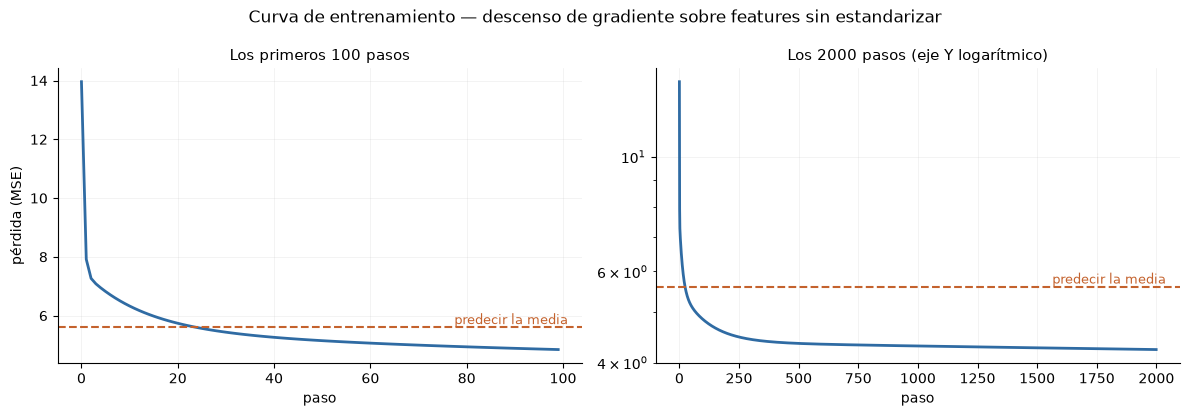

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# panel izquierdo: los 100 primeros pasos
ax1.plot(historial[:100], color="#2f6ba3", linewidth=2)
ax1.set_title("Los primeros 100 pasos", fontsize=11)
ax1.set_xlabel("paso"); ax1.set_ylabel("pérdida (MSE)")

# panel derecho: los 2000, en escala log para ver el detalle del final
ax2.plot(historial, color="#2f6ba3", linewidth=2)
ax2.set_yscale("log")
ax2.set_title("Los 2000 pasos (eje Y logarítmico)", fontsize=11)
ax2.set_xlabel("paso")

for ax in (ax1, ax2):
    ax.axhline(5.608, color="#c4622d", linestyle="--", linewidth=1.5)
    ax.text(ax.get_xlim()[1] * 0.98, 5.608, " predecir la media ", color="#c4622d",
            fontsize=9, ha="right", va="bottom")
    ax.grid(alpha=0.2, linewidth=0.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.suptitle("Curva de entrenamiento — descenso de gradiente sobre features sin estandarizar", fontsize=12)
fig.tight_layout()
fig.savefig("../figuras/02_curva_entrenamiento.png", dpi=150)
plt.show()

Cómo se lee esta curva:

- **El primer paso hace casi todo el trabajo**: de 13.96 a 7.92. Tiene sentido — partir de "predecir
  0 siempre" es tan malo que cualquier corrección ayuda muchísimo.
- **Luego se aplana muy rápido.** Entre el paso 100 (4.84) y el 2000 (4.24) apenas gana medio punto
  en 1900 pasos. Eso **no** significa que haya llegado al mínimo: significa que está bajando por un
  valle larguísimo y estrecho, dando pasitos diminutos. (Con 20 000 pasos llega a 3.69, y sigue
  bajando.)
- **Cruza el listón naranja**, eso sí: 4.24 frente a 5.61. El modelo ha aprendido algo real de la
  estructura química. RMSE = **2.06** contra 2.37 del modelo tonto.

Pero es una victoria pobre, y el motivo es el que anticipamos: **las features tienen escalas
incompatibles**. Mira el bias después de 2000 pasos:

In [17]:
print(f"bias tras 2000 pasos:  b = {float(b):+.5f}")
print(f"donde deberia estar:   b ≈ {float(jnp.mean(y)):+.2f}  (la solubilidad media)")

bias tras 2000 pasos:  b = -0.00173
donde deberia estar:   b ≈ -2.89  (la solubilidad media)


El bias **no se ha movido**: va por −0.002 cuando debería andar cerca de −2.89. Con
$\eta = 10^{-6}$ y un gradiente de ≈ 5.8, cada paso lo mueve $6 \times 10^{-6}$. Necesitaría del
orden de **medio millón de pasos** solo para colocar el bias.

El modelo está compensando esa incapacidad a base de retorcer los pesos de las features grandes,
que es una forma malísima de ajustar.

#### ¿Y si subimos el learning rate?

Es la reacción natural: si va lento, da pasos más grandes. Probemos con $\eta = 10^{-5}$, diez veces
mayor:

In [18]:
w_test = jnp.zeros(17)
b_test = 0.0

print("eta = 1e-5:")
for paso in range(8):
    l = float(loss_wrapper(w_test, b_test, X, y))
    print(f"  paso {paso}: loss = {l:.4g}")
    gw, gb = loss_grad_jit(w_test, b_test, X, y)
    w_test = w_test - 1e-5 * gw
    b_test = b_test - 1e-5 * gb

eta = 1e-5:
  paso 0: loss = 13.96
  paso 1: loss = 914.8
  paso 2: loss = 1.287e+05
  paso 3: loss = 1.823e+07
  paso 4: loss = 2.582e+09
  paso 5: loss = 3.658e+11
  paso 6: loss = 5.181e+13
  paso 7: loss = 7.339e+15


**La pérdida explota**: 13.96 → 915 → 128 000 → 18 millones... y en pocos pasos más se va a `nan`
(*not a number*, el desbordamiento numérico). En dos zancadas el modelo es infinitamente peor que
cuando empezó.

Esto es el paso demasiado grande de la analogía: saltas al otro lado del valle, caes **más arriba**
de donde estabas, el gradiente allí es aún mayor, el siguiente salto es aún más largo... y se
realimenta hasta el infinito. Se llama **divergencia**, y es el fallo nº 1 al entrenar cualquier
modelo. Si alguna vez ves `nan` en tu pérdida, el 90 % de las veces es esto.

Así que estamos atrapados entre dos paredes:

- $\eta = 10^{-5}$ → **diverge**.
- $\eta = 10^{-6}$ → **converge, pero desesperadamente lento** y el bias ni se entera.

**No hay ningún learning rate bueno**, y no es culpa del algoritmo: es culpa de que `BertzCT` valga
miles y `NumHDonors` valga 3. La solución no es tocar $\eta$, es **arreglar las features**.

Y eso es exactamente lo que vamos a hacer en 2.3.8, con la estandarización. Antes, en 2.3.7, una
mejora distinta: el **batching**.

---

### 2.3.7 Batching: entrenar con trocitos

Antes de arreglar el problema de las escalas, una mejora independiente y que se usa **siempre**.

Fíjate en lo que hemos hecho hasta ahora: cada paso de entrenamiento calcula el gradiente usando
**las 9982 moléculas**, y con todo ese trabajo hace **una sola** actualización de los pesos. Eso se
llama **full-batch gradient descent**, y es un desperdicio.

La alternativa: coger un puñadito de moléculas, calcular el gradiente **solo con ellas**, actualizar,
y pasar al siguiente puñado. Ese puñado se llama **batch** (lote) o **mini-batch**.

El vocabulario, que es el que usa todo el mundo:

| Término | Qué significa |
|---|---|
| **batch** | el grupo de moléculas con el que calculas un gradiente |
| **batch size** | cuántas moléculas hay en él (32, 64, 128... casi siempre potencias de 2) |
| **step** / iteración | una actualización de los pesos = un batch |
| **epoch** (época) | una pasada completa por **todos** los datos |
| **SGD** | *stochastic gradient descent*: descenso de gradiente con batches |

Con 9982 moléculas y batch de 32: una época son $311$ actualizaciones,
en vez de 1.

#### ¿Por qué funciona esto?

El gradiente de un batch de 32 **no es** el gradiente verdadero: es una **estimación ruidosa** de él.
Pero es una estimación *insesgada* — de media apunta en la dirección correcta. Y resulta que es
mucho mejor dar 312 pasos aproximados que 1 paso perfecto.

La "S" de SGD (*stochastic*, estocástico) viene precisamente de ese ruido. Y el ruido, además de
salir gratis, tiene una ventaja: **ayuda a escapar de mínimos malos**. Un valle poco profundo del
que el descenso exacto no saldría nunca, el ruido te lo hace saltar. En modelos lineales esto da
igual (solo hay un mínimo), pero en redes neuronales es decisivo.

#### Barajar es obligatorio

Antes de cada época hay que **mezclar** el orden de las moléculas. Si no, todos los batches del
primer lote contendrían siempre las mismas moléculas, y encima nuestro CSV está **ordenado por
fuente** (mira la columna `Group`). Sin barajar, el modelo vería una época entera de moléculas de
un solo origen experimental, luego otra entera de otro, y los pesos irían dando bandazos.

In [19]:
def entrenar_sgd(X, y, eta, batch_size, epocas, seed=0):
    """Descenso de gradiente estocastico. Devuelve (w, b, perdida_de_cada_batch)."""
    N = X.shape[0]
    w = jnp.zeros(X.shape[1])
    b = 0.0
    historial = []
    rng = np.random.default_rng(seed)

    for epoca in range(epocas):
        orden = rng.permutation(N)                     # barajar antes de cada epoca
        for inicio in range(0, N - batch_size + 1, batch_size):
            idx = orden[inicio:inicio + batch_size]
            x_batch, y_batch = X[idx], y[idx]

            historial.append(float(loss_wrapper(w, b, x_batch, y_batch)))
            grad_w, grad_b = loss_grad_jit(w, b, x_batch, y_batch)
            w = w - eta * grad_w
            b = b - eta * grad_b

    return w, b, historial


w_sgd, b_sgd, hist_sgd = entrenar_sgd(X, y, eta=1e-6, batch_size=32, epocas=1)

loss_sgd = float(loss_wrapper(w_sgd, b_sgd, X, y))
print(f"SGD: 1 época = {len(hist_sgd)} actualizaciones")
print(f"  pérdida sobre TODO el dataset = {loss_sgd:.4f}   RMSE = {loss_sgd ** 0.5:.3f}")
print()
print(f"full-batch, 2000 pasos          = 4.2383   RMSE = 2.059")
print(f"(y el full-batch necesitó {2000 * 9982 // (len(hist_sgd) * 32):.0f}x más cálculo de gradiente)")

SGD: 1 época = 311 actualizaciones
  pérdida sobre TODO el dataset = 4.4475   RMSE = 2.109

full-batch, 2000 pasos          = 4.2383   RMSE = 2.059
(y el full-batch necesitó 2006x más cálculo de gradiente)


**311 actualizaciones baratas igualan a 2000 caras.** El full-batch procesó 20 millones de
moléculas-gradiente; el SGD, 10 000. Unas 2000 veces menos trabajo para el mismo resultado.

Por eso **nadie entrena con full-batch**. Todo el deep learning moderno es SGD con batches.

Dibujemos la curva. Ojo, que tiene una pinta muy distinta a la anterior:

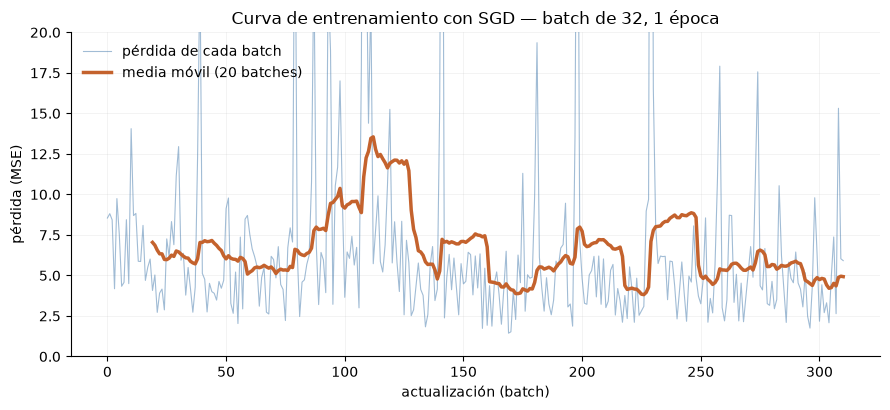

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(hist_sgd, color="#2f6ba3", linewidth=0.8, alpha=0.45, label="pérdida de cada batch")

# media movil: la tendencia por debajo del ruido
ventana = 20
media_movil = np.convolve(hist_sgd, np.ones(ventana) / ventana, mode="valid")
ax.plot(range(ventana - 1, len(hist_sgd)), media_movil,
        color="#c4622d", linewidth=2.5, label=f"media móvil ({ventana} batches)")

ax.set_xlabel("actualización (batch)")
ax.set_ylabel("pérdida (MSE)")
ax.set_title("Curva de entrenamiento con SGD — batch de 32, 1 época")
ax.set_ylim(0, 20)
ax.legend(frameon=False)
ax.grid(alpha=0.2, linewidth=0.5)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("../figuras/02_curva_sgd.png", dpi=150)
plt.show()

**La curva es peluda, y eso es normal.** Cada punto azul es la pérdida de un batch de 32 moléculas
distintas: si a un batch le tocan tres organoclorados imposibles, su pérdida se dispara aunque el
modelo esté mejorando. El ruido es de los **datos del batch**, no del entrenamiento.

Por eso siempre se mira la **media móvil** (la línea naranja): promedia los últimos 20 batches y
deja ver la tendencia real, que baja limpiamente.

Regla práctica que te vale para todo el libro: **nunca juzgues un entrenamiento por la pérdida de un
batch suelto.** Mira la tendencia, o mejor, la pérdida sobre el conjunto entero cada época.

Lo que **no** ha arreglado el batching: el bias sigue sin moverse, y seguimos con $\eta = 10^{-6}$
porque si no, diverge. El problema de las escalas sigue ahí intacto. Vamos a por él.

---

### 2.3.8 Estandarizar: la solución

Todo nuestro problema se resume en una frase: **`BertzCT` vale miles y `NumHDonors` vale 3.**

La solución es poner todas las features en la misma escala antes de entrenar. La receta estándar se
llama **estandarización** (o *z-score*):

$$ \tilde{x}_j = \frac{x_j - \bar{x}_j}{\sigma_j} $$

Para **cada columna** por separado: le restas su media y la divides por su desviación típica.

El resultado: cada feature pasa a tener **media 0 y desviación típica 1**. `BertzCT` y `NumHDonors`
se vuelven comparables, y un valor de $+2$ significa lo mismo en las dos ("dos desviaciones típicas
por encima de lo normal").

Lo importante es que **no se pierde información**: es una transformación lineal y reversible. Solo
cambian las unidades en las que el modelo mide cada descriptor. Lo que sí cambia, radicalmente, es
la forma del paisaje de la pérdida: pasa de ser un cañón larguísimo y estrechísimo (donde cualquier
paso decente en una dirección te despeña en otra) a algo mucho más redondo, por el que se baja en
línea recta.

> ⚠️ **Un aviso para el capítulo 3.** Aquí calculamos la media y la desviación con **todo** el
> dataset, siguiendo al libro. Cuando separemos datos de entrenamiento y de test, eso estará **mal**:
> hay que calcularlas **solo con los datos de entrenamiento** y aplicar esos mismos números al test.
> Si no, información del test se cuela en el entrenamiento — se llama **data leakage** y hace que tu
> modelo parezca mejor de lo que es. Recuérdalo.

In [21]:
# media y desviacion tipica de CADA columna (axis=0 = a lo largo de las filas)
medias = X.mean(axis=0)
desviaciones = X.std(axis=0)

X_std = (X - medias) / desviaciones

# comprobacion
print(f"{'feature':22s} {'media orig':>12s} {'std orig':>12s} {'media std':>11s} {'std std':>9s}")
for i, nombre in enumerate(feature_names):
    print(f"{nombre:22s} {medias[i]:12.2f} {desviaciones[i]:12.2f} "
          f"{float(X_std[:, i].mean()):11.2e} {float(X_std[:, i].std()):9.2f}")

feature                  media orig     std orig   media std   std std
MolWt                        266.67       184.17   -2.11e-07      1.00
MolLogP                        1.98         3.52   -1.83e-08      1.00
MolMR                         66.79        46.52    1.72e-09      1.00
HeavyAtomCount                17.37        12.24    6.27e-08      1.00
NumHAcceptors                  3.49         3.50    3.06e-08      1.00
NumHDonors                     1.11         1.49    3.82e-09      1.00
NumHeteroatoms                 5.20         4.74   -4.89e-08      1.00
NumRotatableBonds              4.07         5.65    3.06e-09      1.00
NumValenceElectrons           94.24        64.75   -6.50e-09      1.00
NumAromaticRings               1.07         1.31   -1.87e-08      1.00
NumSaturatedRings              0.29         0.88   -1.53e-08      1.00
NumAliphaticRings              0.45         1.05   -6.50e-09      1.00
RingCount                      1.52         1.64    1.72e-08      1.00
TPSA  

Columna a columna: las medias originales van de 0.3 a 1000 y las desviaciones de 0.6 a 1400. Después
de estandarizar, **todas** tienen media ≈ 0 (los `e-08` son ruido de coma flotante) y desviación
exactamente 1.

Ahora el gradiente ya no hereda escalas dispares, y podemos subir el learning rate. Antes estábamos
clavados en $10^{-6}$; ahora probamos con $\eta = 0.1$ — **cien mil veces mayor**:

In [22]:
eta = 0.1
w_std = jnp.zeros(17)
b_std = 0.0
hist_std = []

for paso in range(2000):
    hist_std.append(float(loss_wrapper(w_std, b_std, X_std, y)))
    grad_w, grad_b = loss_grad_jit(w_std, b_std, X_std, y)
    w_std = w_std - eta * grad_w
    b_std = b_std - eta * grad_b

loss_std = float(loss_wrapper(w_std, b_std, X_std, y))

for p in (0, 10, 100, 500, 2000):
    valor = hist_std[p] if p < len(hist_std) else loss_std
    print(f"paso {p:5d}: loss = {valor:7.4f}")
print()
print(f"bias aprendido:  b = {float(b_std):+.3f}")
print(f"media real de y:     {float(jnp.mean(y)):+.3f}   <- ahora SI lo encuentra")

paso     0: loss = 13.9592
paso    10: loss =  3.2513
paso   100: loss =  2.8336
paso   500: loss =  2.7699
paso  2000: loss =  2.7474

bias aprendido:  b = -2.890
media real de y:     -2.890   <- ahora SI lo encuentra


Dos cosas que mirar:

1. **En 10 pasos** ya está en 3.25 — mejor de lo que el modelo sin estandarizar lograba en 2000.
2. **El bias vale −2.890**, exactamente la solubilidad media. Lo que antes no lograba ni en medio
   millón de pasos, ahora lo clava enseguida.

¿Y está bien del todo? Para un modelo lineal se puede calcular la solución **exacta** con álgebra
(mínimos cuadrados), así que podemos comprobar si el descenso de gradiente ha llegado al fondo:

In [23]:
# solucion exacta por minimos cuadrados, para saber cual es el minimo real
A = np.hstack([np.array(X_std), np.ones((X_std.shape[0], 1))])
solucion_exacta, *_ = np.linalg.lstsq(A, np.array(y), rcond=None)
loss_optimo = float(np.mean((A @ solucion_exacta - np.array(y)) ** 2))

print(f"{'modelo':38s} {'loss':>8s} {'RMSE':>8s}")
print("-" * 56)
print(f"{'pesos a cero':38s} {13.959:8.3f} {3.736:8.3f}")
print(f"{'predecir la media (el listón)':38s} { 5.608:8.3f} {2.368:8.3f}")
print(f"{'lineal, SIN estandarizar (2000 pasos)':38s} { 4.238:8.3f} {2.059:8.3f}")
print(f"{'lineal, estandarizado (2000 pasos)':38s} {loss_std:8.3f} {loss_std ** 0.5:8.3f}")
print(f"{'óptimo exacto (mínimos cuadrados)':38s} {loss_optimo:8.3f} {loss_optimo ** 0.5:8.3f}")

modelo                                     loss     RMSE
--------------------------------------------------------
pesos a cero                             13.959    3.736
predecir la media (el listón)             5.608    2.368
lineal, SIN estandarizar (2000 pasos)     4.238    2.059
lineal, estandarizado (2000 pasos)        2.747    1.658
óptimo exacto (mínimos cuadrados)         2.708    1.646


**El descenso de gradiente ha llegado prácticamente al óptimo** (2.747 frente a 2.708). La diferencia es
del 1.4 % y se cerraría con más pasos.

El recorrido completo, en RMSE (unidades de log-solubilidad):

| Modelo | RMSE |
|---|---|
| predecir 0 | 3.74 |
| predecir la media | 2.37 |
| lineal sin estandarizar | 2.06 |
| **lineal estandarizado** | **1.66** |

Hemos pasado de 2.37 a 1.66: un **30 % menos de error** que el modelo que no mira la molécula. Con
17 numeritos y una suma ponderada. Está bien para lo simple que es — aunque 1.66 unidades de log
siguen siendo un factor de 45 en concentración, así que tampoco vayas a fiarte de esto para nada real.

#### El regalo envenenado: ahora los pesos son comparables

Con las features estandarizadas, todos los pesos están en las mismas unidades, así que **por fin se
pueden comparar entre sí**. La tentación es leerlos como "importancia de cada descriptor".
Vamos a hacerlo y a ver qué pasa:

In [24]:
orden = np.argsort(-np.abs(np.array(w_std)))

print(f"{'feature':22s} {'peso':>9s} {'r (de 2.3.4)':>14s}")
print("-" * 47)
for i in orden:
    nombre = feature_names[i]
    print(f"{nombre:22s} {float(w_std[i]):+9.3f} {corr[nombre]:+14.2f}")

feature                     peso   r (de 2.3.4)
-----------------------------------------------
BertzCT                   +2.073          -0.29
LabuteASA                 -1.648          -0.35
NumValenceElectrons       +1.576          -0.35
MolLogP                   -1.564          -0.61
HeavyAtomCount            -1.477          -0.35
MolMR                     +0.797          -0.42
NumAromaticRings          -0.631          -0.34
RingCount                 -0.608          -0.33
MolWt                     -0.592          -0.37
NumHeteroatoms            -0.554          -0.04
NumHAcceptors             +0.339          +0.04
NumRotatableBonds         +0.247          -0.22
TPSA                      -0.245          +0.11
NumHDonors                +0.235          +0.19
NumSaturatedRings         +0.213          -0.04
NumAliphaticRings         -0.165          -0.09
BalabanJ                  -0.042          +0.04


Esto es un disparate químico, y es **exactamente** lo que predijimos en 2.3.4:

| Feature | Peso | $r$ real (2.3.4) | ¿Cuadra? |
|---|---|---|---|
| `BertzCT` | **+2.07** | −0.29 | ❌ signo invertido |
| `LabuteASA` | −1.65 | −0.35 | ✅ |
| `NumValenceElectrons` | **+1.58** | −0.35 | ❌ signo invertido |
| `MolLogP` | −1.56 | −0.61 | ✅ |
| `HeavyAtomCount` | −1.48 | −0.35 | ✅ |
| `MolMR` | **+0.80** | −0.42 | ❌ signo invertido |
| `TPSA` | **−0.25** | +0.11 | ❌ signo invertido |

- Los **cinco descriptores de tamaño** (`BertzCT`, `LabuteASA`, `NumValenceElectrons`,
  `HeavyAtomCount`, `MolMR`) tienen pesos grandes y **de signos opuestos entre sí**, cancelándose
  unos a otros. El modelo ha aprendido *diferencias* entre maneras de medir el tamaño, no un efecto
  físico. Los tres con el signo invertido son justo los que no deberían estar ahí solos.
- **`TPSA` = −0.25**, negativo, cuando su correlación era **+0.11** y químicamente *sabemos* que más
  superficie polar es más soluble. El modelo le ha puesto el signo al revés.
- **`MolLogP` = −1.56** sí tiene el signo y la magnitud que esperabas. Es la única feature del grupo
  de cabeza sin gemelas en el dataset, y por eso es la única cuyo peso se puede leer.

Esto es la **multicolinealidad** en acción. Cuando cinco features dicen casi lo mismo, hay
**infinitas** combinaciones de pesos que dan la misma predicción, y el descenso de gradiente
aterriza en una cualquiera — la que le pille de camino desde donde empezó. Los pesos individuales no
significan nada; solo su efecto conjunto.

Comprobación de que esto no es un fallo del entrenamiento: la pérdida es 2.747, prácticamente el
óptimo matemático. **El modelo predice igual de bien con estos pesos absurdos.** Ese es justo el
problema.

**La lección, que vale para todo el libro:**

> Un modelo puede **predecir** bien y ser completamente inútil para **explicar**. Son dos objetivos
> distintos y hay que decidir cuál quieres antes de elegir el modelo.

Si quieres entender qué hace soluble a una molécula, este modelo no sirve — necesitarías quitar
features redundantes, o usar regularización (capítulo 3), o técnicas de interpretabilidad
(capítulo 11). Si quieres un número rápido, sirve.

En 2.3.9 lo evaluamos como es debido, con el **parity plot**.

---

### 2.3.9 Evaluar el modelo: el parity plot

Tenemos un número: RMSE = 1.66. Está bien para comparar modelos, pero **no dice dónde falla**.
Un RMSE de 1.66 puede ser un modelo que se equivoca 1.66 en todas las moléculas por igual, o uno
que clava 9000 y se estrella con 900. Son situaciones completamente distintas y el número no las
distingue.

Para eso está el **parity plot** (gráfico de paridad): un punto por molécula, con el **valor real**
en el eje X y el **valor predicho** en el eje Y.

La clave es la **diagonal $y = x$**: ahí es donde caerían los puntos de un modelo perfecto.

- Punto **por encima** de la diagonal → el modelo predice **más soluble** de lo que es.
- Punto **por debajo** → predice **menos soluble**.
- Cuanto más se aleja un punto de la diagonal, peor la predicción de esa molécula.

Es la gráfica estándar para evaluar cualquier regresión, y la vas a ver en todos los papers de ML
en química.

In [25]:
y_real = np.array(y)
y_pred = np.array(linear_model(X_std, w_std, b_std))
residuos = y_pred - y_real          # error: positivo = predice MAS soluble de lo que es

r = np.corrcoef(y_pred, y_real)[0, 1]
rmse = float(np.sqrt(np.mean(residuos ** 2)))
mae = float(np.mean(np.abs(residuos)))

print(f"r    = {r:.3f}        (correlación predicho vs real)")
print(f"r²   = {r ** 2:.3f}        (fracción de la varianza explicada)")
print(f"RMSE = {rmse:.3f}        (error típico, unidades de log mol/L)")
print(f"MAE  = {mae:.3f}        (error absoluto medio)")
print()
print(f"rango real:     [{y_real.min():7.2f}, {y_real.max():6.2f}]   desviación típica {y_real.std():.2f}")
print(f"rango predicho: [{y_pred.min():7.2f}, {y_pred.max():6.2f}]   desviación típica {y_pred.std():.2f}")

r    = 0.714        (correlación predicho vs real)
r²   = 0.510        (fracción de la varianza explicada)
RMSE = 1.658        (error típico, unidades de log mol/L)
MAE  = 1.229        (error absoluto medio)

rango real:     [ -13.17,   2.14]   desviación típica 2.37
rango predicho: [ -29.84,   7.84]   desviación típica 1.69


Tres métricas y dos rangos. Qué significa cada cosa:

- **$r = 0.714$** — la correlación entre lo predicho y lo real. Compárala con el $r = -0.61$ de
  `MolLogP` sola: combinando las 17 features hemos subido a 0.71.
- **$r^2 = 0.510$** — la **fracción de la varianza explicada**. El modelo captura el **51 %** de la
  variabilidad de la solubilidad; el 49 % restante se le escapa. Es la métrica que se suele
  reportar en los papers.
- **RMSE = 1.658** vs **MAE = 1.229** — el RMSE es mayor que el MAE **siempre**, y cuánto mayor te
  dice cuánto pesan los errores grandes. Aquí la diferencia es notable: hay una minoría de
  moléculas donde el modelo se estrella.
- **Las desviaciones típicas no cuadran**: lo real tiene 2.37, lo predicho solo 1.69. **El modelo
  predice un rango más estrecho que la realidad.** Esto tiene nombre y lo vemos en la gráfica.

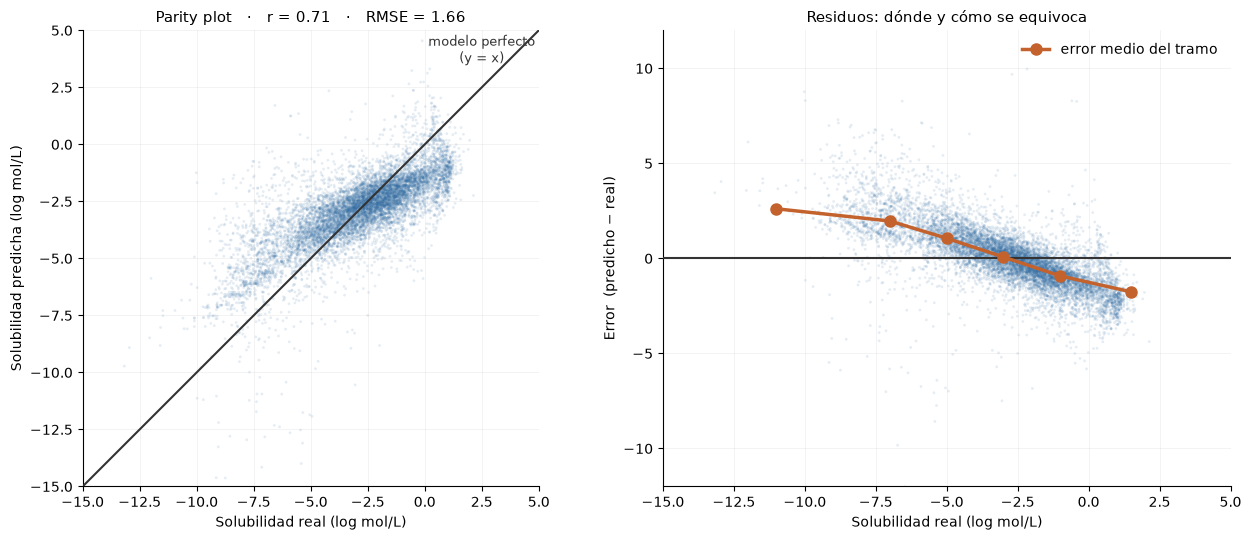

(11 moléculas con predicción fuera del recuadro, no se ven)


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# --- panel 1: parity plot ---
ax1.scatter(y_real, y_pred, s=4, alpha=0.12, color="#2f6ba3", edgecolors="none", rasterized=True)

lims = (-15, 5)
ax1.plot(lims, lims, color="#333", linewidth=1.5, linestyle="-", zorder=3)
ax1.text(2.5, 3.6, "modelo perfecto\n(y = x)", fontsize=9, color="#333", ha="center")

ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_aspect("equal")
ax1.set_xlabel("Solubilidad real (log mol/L)")
ax1.set_ylabel("Solubilidad predicha (log mol/L)")
ax1.set_title(f"Parity plot   ·   r = {r:.2f}   ·   RMSE = {rmse:.2f}", fontsize=11)

# --- panel 2: error frente al valor real ---
ax2.scatter(y_real, residuos, s=4, alpha=0.12, color="#2f6ba3", edgecolors="none", rasterized=True)
ax2.axhline(0, color="#333", linewidth=1.5, zorder=3)

# sesgo medio por tramos
bordes = np.array([-14, -8, -6, -4, -2, 0, 3])
centros = (bordes[:-1] + bordes[1:]) / 2
sesgos = [residuos[(y_real >= lo) & (y_real < hi)].mean() for lo, hi in zip(bordes[:-1], bordes[1:])]
ax2.plot(centros, sesgos, "o-", color="#c4622d", linewidth=2.5, markersize=8,
         zorder=4, label="error medio del tramo")

ax2.set_xlim(lims); ax2.set_ylim(-12, 12)
ax2.set_xlabel("Solubilidad real (log mol/L)")
ax2.set_ylabel("Error  (predicho − real)")
ax2.set_title("Residuos: dónde y cómo se equivoca", fontsize=11)
ax2.legend(frameon=False, loc="upper right")

for ax in (ax1, ax2):
    ax.grid(alpha=0.2, linewidth=0.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("../figuras/02_parity_plot.png", dpi=150)
plt.show()

fuera = int(((y_pred < lims[0]) | (y_pred > lims[1])).sum())
print(f"({fuera} moléculas con predicción fuera del recuadro, no se ven)")

#### Qué se ve: tres patologías

**1. La nube está "aplastada" contra la horizontal.** Si sigues la masa de puntos, no va paralela a
la diagonal: va más tumbada. El modelo **comprime el rango** — se acobarda y tira hacia la media.
Es un fenómeno universal de los modelos de regresión y se llama **regresión a la media**:
ante la duda, predecir cerca del promedio es lo que minimiza el error cuadrático. Por eso la
desviación típica de lo predicho (1.69) es menor que la real (2.37).

**2. El error es sistemático, no aleatorio** (panel derecho, línea naranja):

| Solubilidad real | n | Error medio | RMSE del tramo |
|---|---|---|---|
| −14 a −8 (insolubles extremos) | 280 | **+2.61** | 3.21 |
| −8 a −6 | 858 | +1.97 | 2.83 |
| −6 a −4 | 1732 | +1.06 | 1.72 |
| −4 a −2 (**el grueso**) | 3209 | +0.07 | **0.95** |
| −2 a 0 | 2845 | −0.92 | 1.35 |
| 0 a +3 (muy solubles) | 1058 | **−1.76** | 2.06 |

Léelo así: en las moléculas **muy insolubles** el error medio es **+2.61**, o sea el modelo las
predice **2.6 unidades más solubles de lo que son** — un factor de 400 en concentración. Y en las
**muy solubles** hace lo contrario (−1.76). Es la misma compresión del punto 1, ahora en números.

Donde sí funciona es en la zona central (−4 a −2), con un RMSE de **0.95** y sin sesgo. Y esa zona
es justo **donde hay más datos** (3209 moléculas). No es casualidad: el modelo se ajusta donde hay
ejemplos y abandona las colas, exactamente como avisamos al ver el histograma en 2.3.2.

**3. Hay predicciones absurdas.** El modelo llega a predecir **−29.8**, un valor que no existe en la
naturaleza (el mínimo real es −13.2). Eso no es "equivocarse un poco": es el modelo lineal
**extrapolando** sin freno. Una recta no tiene tope — le metes un valor grande de una feature y te
escupe lo que sea. Las redes neuronales tienen el mismo problema, y es una de las razones por las
que hay que vigilar el **dominio de aplicabilidad** de un modelo.

Vamos a mirar esas catástrofes de cerca:

In [27]:
peores = np.argsort(-np.abs(residuos))[:5]

print("Las 5 peores predicciones:\n")
for i in peores:
    print(f"  {soldata['Name'].iloc[i][:62]}")
    print(f"     real = {y_real[i]:+6.2f}   predicho = {y_pred[i]:+7.2f}   error = {residuos[i]:+6.2f}")
    print(f"     MolWt = {soldata['MolWt'].iloc[i]:.0f}   MolLogP = {soldata['MolLogP'].iloc[i]:.1f}")
    print()

Las 5 peores predicciones:

  1,3-dimethyl-5-propylbenzene; 6,6,22,22-tetrabutyloctapentacon
     real =  -6.81   predicho =  -29.84   error = -23.03
     MolWt = 2561   MolLogP = 68.5

  (2-phenylbutan-2-yl)benzene; (2-phenylethyl)benzene; 1,2,4,5-t
     real =  -4.59   predicho =  -21.29   error = -16.70
     MolWt = 1588   MolLogP = 34.0

  1,3-xylene; 1,4-diethylcyclohexane; 8,15-diethylhexacosane; an
     real =  -5.41   predicho =  -21.70   error = -16.29
     MolWt = 1591   MolLogP = 40.8

  1,2,3,4-tetrahydronaphthalene; 1,3,5-trimethylbenzene; 1,4-die
     real =  -3.54   predicho =  -16.35   error = -12.81
     MolWt = 1040   MolLogP = 21.8

  dialuminium tris[2-(2,4,5,7-tetrabromo-6-oxido-3-oxoxanthen-9-
     real =  -6.49   predicho =  -19.12   error = -12.63
     MolWt = 2405   MolLogP = 22.2



Fíjate en los **nombres**: llevan **puntos y coma**. No son moléculas, son **mezclas** de varios
compuestos metidas como una sola entrada del dataset.

Y ahí está la trampa: RDKit calcula los descriptores sobre **todos los componentes sumados**. Una
mezcla de cuatro dimetilfenoles (cada uno de peso 122) le sale con `MolWt = 733`. El modelo ve un
peso molecular enorme, concluye "esto es insolubilísimo" y dispara a −29.8, cuando la solubilidad
real de la mezcla es la de sus componentes individuales.

¿Cuántas hay?

In [28]:
mezclas = soldata["Name"].str.contains(";", na=False)

print(f"entradas que son mezclas: {mezclas.sum()} de {len(soldata)}  ({100 * mezclas.mean():.1f} %)")
print()
print(f"{'':22s} {'MolWt medio':>12s} {'RMSE':>8s}")
print(f"{'mezclas':22s} {soldata.loc[mezclas, 'MolWt'].mean():12.1f} "
      f"{np.sqrt(np.mean(residuos[mezclas.values] ** 2)):8.2f}")
print(f"{'compuestos puros':22s} {soldata.loc[~mezclas, 'MolWt'].mean():12.1f} "
      f"{np.sqrt(np.mean(residuos[~mezclas.values] ** 2)):8.2f}")

entradas que son mezclas: 573 de 9982  (5.7 %)

                        MolWt medio     RMSE
mezclas                       338.7     2.31
compuestos puros              262.3     1.61


Un 5.7 % del dataset son mezclas, y el modelo se equivoca claramente más con ellas.

**Esto es un hallazgo de calidad de datos**, del tipo que solo aparece cuando miras los residuos en
vez de quedarte con el RMSE. Es, junto con los 400 `BalabanJ = 0` de 2.3.4, el segundo problema
serio que encontramos en AqSolDB. En un proyecto real la decisión sería filtrar esas entradas antes
de entrenar.

> Esto no es una crítica a AqSolDB — es una base de datos muy buena y muy usada. Es simplemente
> cómo son los datos experimentales reales.

#### El aviso más importante de todo el capítulo

Todo lo anterior —el RMSE de 1.66, el $r^2$ de 0.51, el parity plot— está calculado sobre
**las mismas 9982 moléculas con las que hemos entrenado el modelo**.

Eso es hacer el examen con las soluciones delante.

Un modelo puede sacar un RMSE buenísimo simplemente **memorizando** los datos de entrenamiento, y
luego fallar estrepitosamente con una molécula nueva. Se llama **overfitting** (sobreajuste) y es
*el* problema central del machine learning.

Nuestro modelo lineal tiene solo 18 parámetros para 9982 moléculas, así que memorizar no puede — no
le dan los grados de libertad. Por eso aquí el número es *más o menos* creíble. Pero en cuanto
tengamos modelos con miles o millones de parámetros, evaluar sobre los datos de entrenamiento será
**inútil y engañoso**.

La solución —separar los datos en entrenamiento y test, validación cruzada, cómo reportar
honestamente el rendimiento de un modelo— es **todo el capítulo 3**. Hasta entonces, trata el
RMSE = 1.66 como un número provisional.

---

## Resumen de la sección 2.3

Lo que hemos construido, de principio a fin:

| Paso | Qué hicimos | Resultado |
|---|---|---|
| 2.3.1 | Parsear SMILES/InChI a moléculas con RDKit | dibujos, cordura química |
| 2.3.2 | Histograma de la solubilidad | std = 2.37 → **el listón** |
| 2.3.3 | Mirar las moléculas extremas | los datos son coherentes (con ruido) |
| 2.3.4 | Correlación feature–label | `MolLogP` manda; hay multicolinealidad |
| 2.3.5 | Modelo lineal + MSE | las dos piezas del ML |
| 2.3.6 | Descenso de gradiente con `jax.grad` | funciona, pero las escalas lo ahogan |
| 2.3.7 | Batching (SGD) | 2000× menos cálculo, mismo resultado |
| 2.3.8 | Estandarizar | **RMSE 2.37 → 1.66** |
| 2.3.9 | Parity plot y residuos | dónde falla y por qué |

Las ideas que hay que llevarse:

1. **Mira los datos antes de modelar.** Todo lo importante (multicolinealidad, `BalabanJ = 0`,
   las mezclas) salió de mirar, no de entrenar.
2. **Ten siempre un listón tonto.** Sin el "predecir la media" (2.37), un RMSE de 1.66 no significa nada.
3. **Estandariza las features.** Casi gratis, y es la diferencia entre que el entrenamiento funcione o no.
4. **Predecir ≠ explicar.** Nuestros pesos contradicen la química y aun así el modelo predice bien.
5. **Un número no basta.** El parity plot reveló compresión, sesgo sistemático en las colas y un
   problema de calidad de datos que el RMSE escondía.
6. **Esto todavía no es una evaluación honesta.** Falta el conjunto de test — capítulo 3.

**Siguiente: 2.4, aprendizaje no supervisado.** Cambio de chip: se acabaron las etiquetas. Ahora
buscamos estructura en los datos sin decirle al algoritmo qué es "correcto", con *clustering*.